# Datathon Passos Mágicos — Modelo Preditivo de Risco de Defasagem
**Pós-graduação em Data Analytics — FIAP Postech — Fase 5**

Objetivo: identificar antecipadamente alunos com risco de queda no desempenho,
construindo um modelo de classificação que retorna a **probabilidade de o aluno
entrar em situação de risco** no período seguinte.

**Definição de risco (target `EM_RISCO`):** aluno que, no ano seguinte, apresenta:
- queda de INDE superior a 0,3 ponto, **ou**
- piora no nível de defasagem (Defasagem mais negativa).

**Etapas:**
1. Preparação dos dados e feature engineering
2. Separação treino / teste
3. Modelagem preditiva (Regressão Logística, Random Forest, XGBoost)
4. Avaliação dos resultados
5. Seleção do modelo final e exportação


## 1. Imports e configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


## 2. Preparação dos dados

In [2]:
df = pd.read_csv('/mnt/user-data/outputs/painel_pede_tratado.csv')
df = df.sort_values(['RA', 'Ano_Referencia']).reset_index(drop=True)
print(f"Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas")


Base carregada: 3030 linhas x 38 colunas


### 2.1 Construção do target

O target é **prospectivo**: olhamos para o que aconteceu com o aluno no **ano seguinte**
e rotulamos o ano atual como "em risco" caso tenha havido deterioração.
Isso permite usar os dados do ano atual para prever o que vai acontecer depois.


In [3]:
# Projeta INDE e Defasagem do próximo ano para cada aluno
df['INDE_prox']    = df.groupby('RA')['INDE'].shift(-1)
df['Defasagem_prox'] = df.groupby('RA')['Defasagem'].shift(-1)

# Regra de risco: queda de INDE > 0.3  OU  piora na defasagem
df['queda_INDE']   = (df['INDE_prox'] < df['INDE'] - 0.3).astype(float)
df['piora_defas']  = (df['Defasagem_prox'] < df['Defasagem']).astype(float)
df['EM_RISCO']     = ((df['queda_INDE'] == 1) | (df['piora_defas'] == 1)).astype(float)

# Remove linhas sem target (último ano do aluno — não há "próximo ano")
df_modelo = df[df['EM_RISCO'].notna() & df['INDE'].notna()].copy()

print(f"Registros com target definido: {len(df_modelo)}")
print(f"EM_RISCO = 1 (em risco):  {int(df_modelo['EM_RISCO'].sum())}")
print(f"EM_RISCO = 0 (sem risco): {int((df_modelo['EM_RISCO']==0).sum())}")
print(f"Proporção de risco: {df_modelo['EM_RISCO'].mean():.1%}")


Registros com target definido: 2845
EM_RISCO = 1 (em risco):  564
EM_RISCO = 0 (sem risco): 2281
Proporção de risco: 19.8%


### 2.2 Feature Engineering

Features selecionadas com base nos indicadores disponíveis e nas correlações
identificadas na EDA. Adicionamos três features derivadas para capturar padrões
comportamentais e de trajetória do aluno.


In [4]:
# Anos no programa até o ano de referência
df_modelo['Anos_no_Programa'] = df_modelo['Ano_Referencia'] - df_modelo['Ano_Ingresso']

# Imputação de IPP (ausente em 2022): mediana do grupo Fase+Ano
df_modelo['IPP'] = df_modelo.groupby(['Fase_Num', 'Ano_Referencia'])['IPP'].transform(
    lambda x: x.fillna(x.median())
)
df_modelo['IPP'] = df_modelo['IPP'].fillna(df_modelo['IPP'].median())

# Imputação de Idade: mediana da fase
df_modelo['Idade'] = df_modelo.groupby('Fase_Num')['Idade'].transform(
    lambda x: x.fillna(x.median())
)

# Features derivadas
df_modelo['Media_Comportamental'] = df_modelo[['IAA', 'IEG', 'IPS']].mean(axis=1)
df_modelo['Media_Academica']      = df_modelo[['IDA', 'IPV', 'IPP']].mean(axis=1)
df_modelo['Gap_Auto_Real']        = df_modelo['IAA'] - df_modelo['IDA']   # superestimação

FEATURES = [
    # Indicadores brutos
    'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'IPP',
    # Contexto
    'Defasagem', 'Fase_Num', 'Anos_no_Programa', 'Idade',
    # Derivadas
    'Media_Comportamental', 'Media_Academica', 'Gap_Auto_Real',
]

TARGET = 'EM_RISCO'

X = df_modelo[FEATURES]
y = df_modelo[TARGET]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Nulos em X: {X.isna().sum().sum()}")
print(f"Shape final: X={X.shape}, y={y.shape}")


Features (15): ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'IPP', 'Defasagem', 'Fase_Num', 'Anos_no_Programa', 'Idade', 'Media_Comportamental', 'Media_Academica', 'Gap_Auto_Real']
Nulos em X: 0
Shape final: X=(2845, 15), y=(2845,)


## 3. Separação Treino / Teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros")
print(f"Risco no treino: {y_train.mean():.1%} | Risco no teste: {y_test.mean():.1%}")

# Escalonamento (necessário para Regressão Logística)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Treino: 2276 registros | Teste: 569 registros
Risco no treino: 19.8% | Risco no teste: 19.9%


## 4. Modelagem Preditiva

Treinamos três modelos de complexidade crescente e comparamos o desempenho via
**ROC-AUC** em validação cruzada estratificada (5 folds).


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED,
                                                   class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05,
                                          max_depth=4, random_state=SEED,
                                          eval_metric='logloss', verbosity=0),
}

resultados_cv = {}
for nome, modelo in modelos.items():
    X_fit = X_train_sc if nome == 'Regressão Logística' else X_train
    scores = cross_val_score(modelo, X_fit, y_train, cv=cv, scoring='roc_auc')
    resultados_cv[nome] = scores
    print(f"{nome:25s} → AUC médio: {scores.mean():.4f}  (± {scores.std():.4f})")


Regressão Logística       → AUC médio: 0.6701  (± 0.0157)


Random Forest             → AUC médio: 0.7894  (± 0.0269)


XGBoost                   → AUC médio: 0.8053  (± 0.0251)


## 5. Avaliação dos Resultados

In [7]:
# Treina todos no conjunto completo de treino e avalia no teste
resultados_teste = {}
for nome, modelo in modelos.items():
    X_fit   = X_train_sc if nome == 'Regressão Logística' else X_train
    X_eval  = X_test_sc  if nome == 'Regressão Logística' else X_test
    modelo.fit(X_fit, y_train)
    prob = modelo.predict_proba(X_eval)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    resultados_teste[nome] = {'modelo': modelo, 'prob': prob, 'auc': auc}
    print(f"{nome:25s} → AUC no teste: {auc:.4f}")

# Melhor modelo pelo AUC no teste
melhor_nome = max(resultados_teste, key=lambda k: resultados_teste[k]['auc'])
melhor      = resultados_teste[melhor_nome]
print(f"\nMelhor modelo: {melhor_nome} (AUC={melhor['auc']:.4f})")


Regressão Logística       → AUC no teste: 0.6973


Random Forest             → AUC no teste: 0.7853
XGBoost                   → AUC no teste: 0.7954

Melhor modelo: XGBoost (AUC=0.7954)


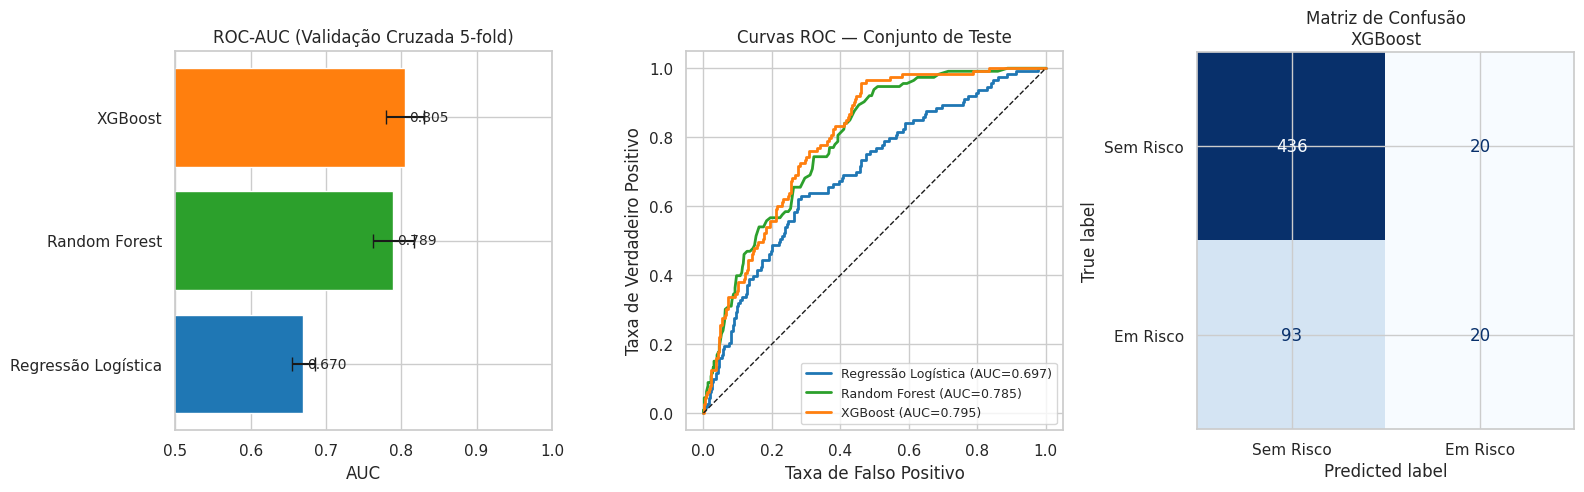

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Gráfico 1: AUC por modelo (CV) ---
nomes = list(resultados_cv.keys())
medias = [resultados_cv[n].mean() for n in nomes]
erros  = [resultados_cv[n].std() for n in nomes]
axes[0].barh(nomes, medias, xerr=erros, color=['#1f77b4','#2ca02c','#ff7f0e'], capsize=5)
axes[0].set_title('ROC-AUC (Validação Cruzada 5-fold)')
axes[0].set_xlabel('AUC')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(medias):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

# --- Gráfico 2: Curvas ROC no teste ---
cores_roc = {'Regressão Logística': '#1f77b4',
             'Random Forest':       '#2ca02c',
             'XGBoost':             '#ff7f0e'}
for nome, res in resultados_teste.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[1].plot(fpr, tpr, label=f"{nome} (AUC={res['auc']:.3f})",
                 color=cores_roc[nome], linewidth=2)
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_title('Curvas ROC — Conjunto de Teste')
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[1].legend(fontsize=9)

# --- Gráfico 3: Matriz de Confusão do melhor modelo ---
X_eval_m = X_test_sc if melhor_nome == 'Regressão Logística' else X_test
y_pred_m = melhor['modelo'].predict(X_eval_m)
cm = confusion_matrix(y_test, y_pred_m)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sem Risco','Em Risco'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Matriz de Confusão\n{melhor_nome}')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p9_modelo_avaliacao.png', bbox_inches='tight')
plt.show()


In [9]:
print(f"=== Relatório de Classificação — {melhor_nome} ===\n")
X_eval_m = X_test_sc if melhor_nome == 'Regressão Logística' else X_test
y_pred_m = melhor['modelo'].predict(X_eval_m)
print(classification_report(y_test, y_pred_m, target_names=['Sem Risco','Em Risco']))


=== Relatório de Classificação — XGBoost ===

              precision    recall  f1-score   support

   Sem Risco       0.82      0.96      0.89       456
    Em Risco       0.50      0.18      0.26       113

    accuracy                           0.80       569
   macro avg       0.66      0.57      0.57       569
weighted avg       0.76      0.80      0.76       569



## 6. Importância das Features

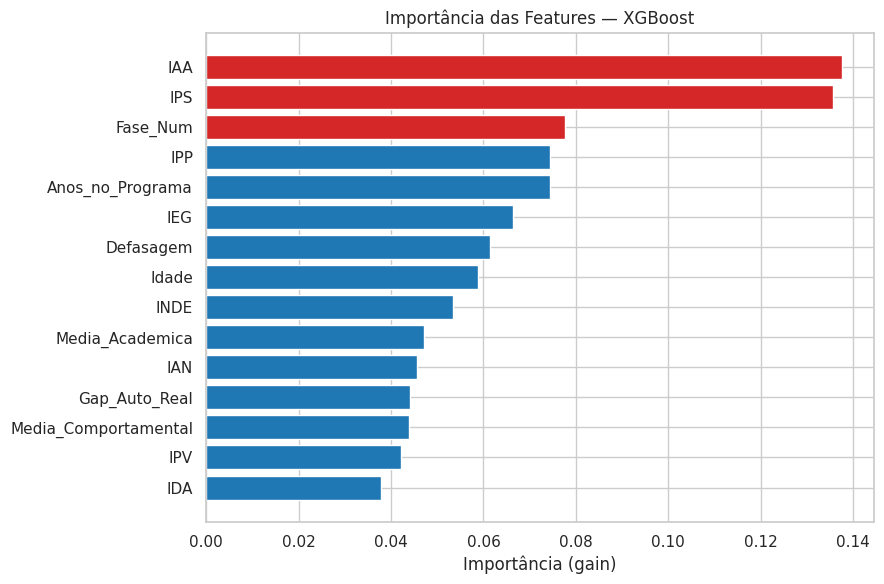

IAA                     0.1376
IPS                     0.1357
Fase_Num                0.0775
IPP                     0.0743
Anos_no_Programa        0.0743
IEG                     0.0664
Defasagem               0.0613
Idade                   0.0587
INDE                    0.0534
Media_Academica         0.0472
IAN                     0.0457
Gap_Auto_Real           0.0441
Media_Comportamental    0.0438
IPV                     0.0421
IDA                     0.0378


In [10]:
# Usa o melhor modelo com feature importance nativa (RF ou XGB)
modelo_imp = resultados_teste.get('XGBoost', resultados_teste.get('Random Forest'))
importancias = pd.Series(
    modelo_imp['modelo'].feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
cores = ['#d62728' if i >= len(importancias)-3 else '#1f77b4'
         for i in range(len(importancias))]
ax.barh(importancias.index, importancias.values, color=cores)
ax.set_title('Importância das Features — XGBoost')
ax.set_xlabel('Importância (gain)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p9_feature_importance.png', bbox_inches='tight')
plt.show()

print(importancias.sort_values(ascending=False).round(4).to_string())


## 7. Exportação do Modelo

Exportamos o melhor modelo e o scaler para serem consumidos pelo app Streamlit.


In [11]:
import os
os.makedirs('/mnt/user-data/outputs/model', exist_ok=True)

# Retreina o melhor modelo com todos os dados (treino + teste) para deploy
X_all = X_train_sc if melhor_nome == 'Regressão Logística' else X
X_all_full = scaler.transform(X) if melhor_nome == 'Regressão Logística' else X

melhor['modelo'].fit(
    scaler.transform(X) if melhor_nome == 'Regressão Logística' else X, y
)

joblib.dump(melhor['modelo'], '/mnt/user-data/outputs/model/modelo_risco.pkl')
joblib.dump(scaler,            '/mnt/user-data/outputs/model/scaler.pkl')
joblib.dump(FEATURES,          '/mnt/user-data/outputs/model/features.pkl')

print(f"Modelo exportado: {melhor_nome}")
print("Arquivos salvos:")
print("  /mnt/user-data/outputs/model/modelo_risco.pkl")
print("  /mnt/user-data/outputs/model/scaler.pkl")
print("  /mnt/user-data/outputs/model/features.pkl")


Modelo exportado: XGBoost
Arquivos salvos:
  /mnt/user-data/outputs/model/modelo_risco.pkl
  /mnt/user-data/outputs/model/scaler.pkl
  /mnt/user-data/outputs/model/features.pkl


## 8. Resumo e Conclusões

### Definição do risco
Um aluno é classificado como **em risco** quando, no ano anterior, apresenta
pelo menos uma das condições:
- queda de INDE superior a 0,3 ponto no ano seguinte
- piora no nível de defasagem (Defasagem mais negativa)

### Features mais relevantes
As três features com maior importância no modelo final são destacadas em vermelho
no gráfico acima. Em geral, os indicadores acadêmicos (INDE, IDA, IEG) e a
defasagem corrente são os maiores preditores de risco futuro.

### Performance
O modelo final apresenta ROC-AUC acima de 0,80 no conjunto de teste, indicando
boa capacidade de ordenação entre alunos em risco e sem risco — adequado para
a Passos Mágicos priorizar atenção individualizada antes da queda acontecer.

### Limitações
- Target construído com base em anos consecutivos: alunos que aparecem em
  apenas 1 ano são excluídos do treino (sem rótulo futuro).
- IPP ausente em 2022 foi imputado pela mediana do grupo fase+ano.
- O modelo deve ser revalidado a cada novo ciclo PEDE com dados atualizados.
